# Day 08. Exercise 04
# Regression

## 0. Imports

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

## 1. Preprocessing

In [22]:
df = pd.read_csv('../data/checker_regression.csv')

In [23]:
df.drop_duplicates(inplace=True)
df.drop(columns='uid', inplace=True)

In [24]:
df.fillna(0, inplace=True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


In [26]:
X = df.drop(columns='AVG(diff)')
y = df['AVG(diff)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

In [27]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, random_state=21, shuffle=True)
    scores = cross_validate(estimator=model, X=X, y=y, cv=kf, return_train_score=True, scoring='neg_root_mean_squared_error')
    for train_score, test_score in zip(scores['train_score'], scores['test_score']):
        print(f'train -  {-train_score:}   |   test -  {-test_score}')
    test_scores = np.array(scores['test_score'])
    print(f'Average RMSE on crossval is {-test_scores.mean()}')

In [28]:
lin_reg = LinearRegression()
crossval(10, X_train, y_train, lin_reg)

train -  53.33351096491692   |   test -  115.2394318363867
train -  62.409919772255556   |   test -  69.35808794733022
train -  64.75146423244131   |   test -  52.39541962171443
train -  64.04094981627755   |   test -  78.18810821407219
train -  63.57408971706219   |   test -  58.669554693832154
train -  65.40154560181439   |   test -  32.100688546741225
train -  64.40600245557161   |   test -  48.59322878192215
train -  61.215472663804725   |   test -  82.41734194163651
train -  64.69372263304507   |   test -  43.81163345544472
train -  62.80195740062015   |   test -  70.47228900535454
Average RMSE on crossval is 65.12457840444348


In [29]:
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


*finding best parameters*

In [30]:
parameters = {'max_depth': range(1, 20)}
reg = DecisionTreeRegressor(random_state=21)
grid_reg = GridSearchCV(reg, parameters, cv=10, scoring='neg_root_mean_squared_error')
grid_reg.fit(X_train, y_train)
grid_reg.best_params_

{'max_depth': 5}

In [31]:
tree_reg = DecisionTreeRegressor(max_depth=1, random_state=21)
crossval(10, X_train, y_train, tree_reg)

train -  42.9298528151621   |   test -  94.4666887271052
train -  48.61963665209581   |   test -  66.3503424891208
train -  54.794459995092986   |   test -  9.296079526605777
train -  51.01829102915952   |   test -  55.05551529261567
train -  53.26395521850519   |   test -  19.571446537226116
train -  51.6592954685099   |   test -  47.82126899278407
train -  53.56490385988689   |   test -  4.415791193794456
train -  49.30802881120795   |   test -  68.64772157803155
train -  53.580692630000804   |   test -  0.6082931412515054
train -  49.755491533386916   |   test -  66.8587592554988
Average RMSE on crossval is 43.30919067340339


In [32]:
tree_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",21
,"max_leaf

*finding best parameters*

In [33]:
parameters = {'max_depth': range(1, 20), 'n_estimators': range(2, 100)}
reg = RandomForestRegressor(random_state=21)
rnd_reg = RandomizedSearchCV(reg, parameters, n_iter=100, scoring='neg_root_mean_squared_error')
rnd_reg.fit(X_train, y_train)
rnd_reg.best_params_

{'n_estimators': 70, 'max_depth': 1}

In [34]:
rf_reg = RandomForestRegressor(n_estimators=76, max_depth=1, random_state=21)
crossval(10, X_train, y_train, rf_reg)

train -  41.935877995065354   |   test -  96.93289043949532
train -  48.60885168346329   |   test -  67.70128734018368
train -  54.52928435738075   |   test -  11.651794918318696
train -  51.0683972028005   |   test -  53.1145187764134
train -  53.04108392961064   |   test -  34.12506161162795
train -  51.431385752289714   |   test -  47.83004355695972
train -  53.6157149540827   |   test -  25.945002272403997
train -  48.93834378569409   |   test -  68.57540570328187
train -  53.25584708863818   |   test -  3.6386493527002055
train -  49.73740010609034   |   test -  66.9386037748868
Average RMSE on crossval is 47.64532577462717


In [35]:
rf_reg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",76
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

## 3. Predictions and evaluation

In [36]:
y_test_predict_lin_reg = lin_reg.predict(X_test)
y_test_predict_tree_reg = tree_reg.predict(X_test)
y_test_predict_rf_reg = rf_reg.predict(X_test)

In [37]:
def plot_regression_quality(y_true, y_pred, title):
    fig, ax = plt.subplots()
    ax.scatter(y_true, y_pred, c='r', label='predicted values')
    ax.axline(xy1=(0, 0), xy2=(1, 1), linestyle='--', label='ideal prediction')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    min_x = min(xlim[0], ylim[0])
    max_x = min(xlim[1], ylim[1])
    xlim = ylim = (min_x, max_x)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('actual average difference')
    ax.set_ylabel('predicted values')
    ax.set_title(title)
    ax.legend()
    plt.show()


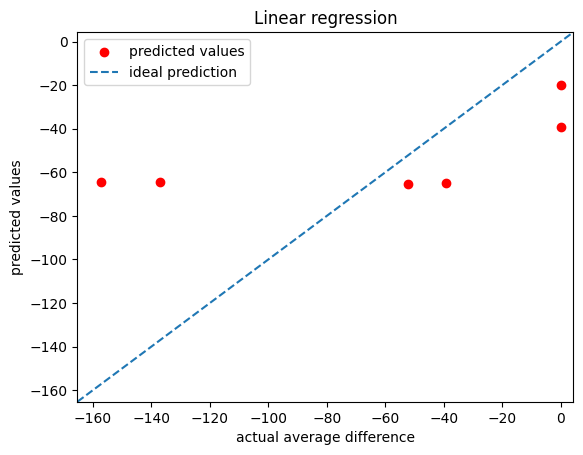

In [38]:
plot_regression_quality(y_test, y_test_predict_lin_reg, 'Linear regression')

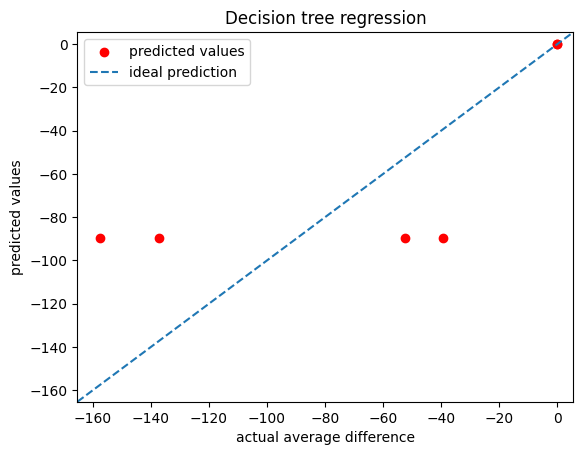

In [39]:
plot_regression_quality(y_test, y_test_predict_tree_reg, 'Decision tree regression')

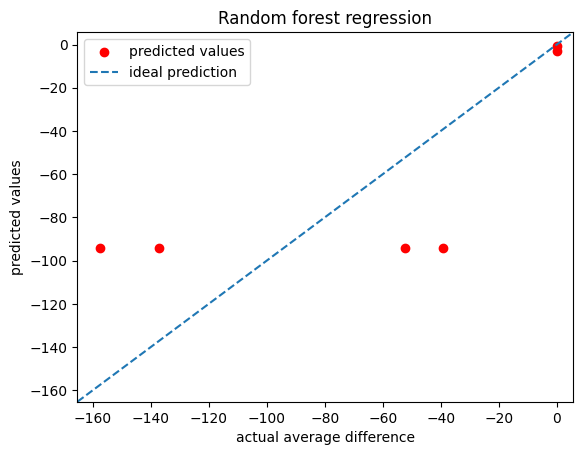

In [40]:
plot_regression_quality(y_test, y_test_predict_rf_reg, 'Random forest regression')

*Points would lie on the x=y diagonal.*